Preditive Exploratory Data Analysis

In [1]:
# Loading relevant libraries.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import tree
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.metrics import confusion_matrix
from sklearn import metrics
from imblearn.over_sampling import SMOTE  
from sklearn.tree import export_graphviz
from sklearn.model_selection import GridSearchCV
from sklearn.cluster import KMeans 
from sklearn.metrics import accuracy_score

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

# Ignoring warnings.
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Loading the data.
study_groups = pd.read_excel('sg_studentdata_cleaned.xlsx')

# Displaying the first few rows of the data.
study_groups.head(10)

,Centre,Programme,Area,Region,Sub Region,Country,Branch URN,Group URN,Lead Source,Student ID,Booking ID,Nationality,IntakeYear,IntakeQuarter,Application Date,Offered Date,Confirmation Date,Arrived Date,Cancellation Date,Completed,Progressed,Registered,Tuition Fees,Net Value,Discount,Discount Type
0,Leeds,Diploma,China,E C1 China,E China,Shanghai,C15433,C15301,Standard Agent Booking,2739037,42573417,Chinese,2023,3,2022-07-02,NaT,NaT,NaT,2022-07-08,NaN,NaN,NaN,19500.0,19500.0,0.0,NaN
1,Cardiff,Foundation,UK EU & Americas,UK & W Europe,UK & W Europe,UK,U19750,U19750,Sponsor,2742709,42960182,Qatari,2023,3,2022-07-04,2022-07-18,NaT,NaT,2023-09-13,NaN,NaN,NaN,20500.0,20500.0,0.0,NaN
2,Sheffield,Foundation,UK EU & Americas,UK & W Europe,UK & W Europe,UK,U19750,U19750,Sponsor,2742709,42730640,Qatari,2023,3,2022-07-04,NaT,NaT,NaT,2023-09-13,NaN,NaN,NaN,24900.0,24900.0,0.0,NaN
3,Durham,Pre Masters,China,N C2 China,N China,Beijing,I1808,I20278,Standard Agent Booking,2690785,43808581,Chinese,2023,3,2022-12-15,2022-12-17,NaT,NaT,2024-01-03,NaN,NaN,NaN,22300.0,22300.0,0.0,NaN
4,Durham,Foundation,ANZ & N Asia,North Asia,Japan,Japan,B12274,E30277,Standard Agent Booking,2732702,42248036,Japanese,2023,3,2022-07-05,2022-07-05,NaT,NaT,2023-03-22,NaN,NaN,NaN,22000.0,22000.0,0.0,NaN
5,Surrey,Foundation,UK EU & Americas,UK & W Europe,UK & W Europe,UK,G19978,G19978,Sponsor,2793392,43832723,Saudi,2023,3,2023-01-07,2023-01-07,NaT,NaT,2024-01-03,NaN,NaN,NaN,17750.0,17750.0,0.0,NaN
6,Lancaster,Foundation,UK EU & Americas,UK & W Europe,UK & W Europe,UK,G20287,G19978,Standard Agent Booking,2743282,42754944,Sudanese,2023,4,2022-07-05,2022-07-05,NaT,NaT,2022-08-19,NaN,NaN,NaN,19500.0,19500.0,0.0,NaN
7,Leeds,Foundation,UK EU & Americas,UK & W Europe,UK & W Europe,UK,E19739,E19739,Sponsor,2741289,42684027,Saudi,2023,3,2022-07-05,2022-07-05,NaT,NaT,2023-07-18,NaN,NaN,NaN,19500.0,19500.0,0.0,NaN
8,Aberdeen,Diploma,South Asia,India,India,India,E31009,E31009,Standard Agent Booking,2823716,43956527,Indian,2023,3,2023-03-25,2023-03-28,2023-04-21,NaT,2024-01-03,NaN,NaN,NaN,16650.0,16650.0,0.0,NaN
9,Sheffield,Pre Masters,China,S W China,S China,Fujian,B30937,C15301,Standard Agent Booking,2660547,39965561,Chinese,2023,3,2022-07-06,2022-07-06,NaT,NaT,2023-04-27,NaN,NaN,NaN,19500.0,19500.0,0.0,NaN


In [3]:
# Determine if data set is balanced.
study_groups['Completed'].value_counts()

Completed
Pass          3333
Fail           635
Terminated     120
Name: count, dtype: int64

In [4]:
# Concat 'IntakeYear' and 'IntakeQuarter' to form 'IntakeYearQuarter'.
study_groups['IntakeYearQuarter'] = study_groups['IntakeYear'].astype(str) + '.' + study_groups['IntakeQuarter'].astype(str)

# Drop columns that are not needed.
study_groups.drop(columns=['Area', 'Region', 'Sub Region',
        'Student ID', 'Booking ID', 'Group URN', 'IntakeYear', 'IntakeQuarter',
       'Application Date', 'Offered Date', 'Confirmation Date', 'Arrived Date',
       'Cancellation Date','Tuition Fees', 'Net Value', 'Discount'], inplace=True)

# Replace 'Yes' and 'No' with True and False respectively.
study_groups['Progressed'] = study_groups['Progressed'].replace({'Yes': 1, 'No': 0})
study_groups['Registered'] = study_groups['Registered'].replace({'Yes': 1, 'No': 0})

# Replace 'Pass' and 'Fail' with 1 and 0 respectively.
study_groups['Completed'] = study_groups['Completed'].map({'Pass': 1, 'Fail': 0, 'Terminated': 0})


# Encode categorical variables.
studygroup_dummies = pd.get_dummies(study_groups, columns=['Centre', 'Country', 'Programme', 'Nationality', 
                                                           'Discount Type', 'Branch URN','Lead Source', 'IntakeYearQuarter'])

# Handle missing values.
studygroup_dummies.fillna(0, inplace=True)

In [5]:
# Define features and target.
X = studygroup_dummies.drop(columns=['Completed'])
y = studygroup_dummies["Completed"]

# Convert categorical labels (if necessary)
y = y.replace({'Pass': 1, 'Fail': 0, 'Terminated': 0})

# Ensure binary and integer format
y = y.astype(int)

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Scale numerical features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [6]:
# Logistic Regression
lr = LogisticRegression()
lr.fit(X_train, y_train)

LogisticRegression()

In [7]:
y_pred_lr = lr.predict(X_test)
print("Logistic Regression:")
print(classification_report(y_test, y_pred_lr))

Logistic Regression:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     20471
           1       1.00      0.98      0.99      1056

    accuracy                           1.00     21527
   macro avg       1.00      0.99      0.99     21527
weighted avg       1.00      1.00      1.00     21527



In [8]:
# Random Forest
rf = RandomForestClassifier()
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
print("Random Forest:")
print(classification_report(y_test, y_pred_rf))

Random Forest:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     20471
           1       1.00      0.98      0.99      1056

    accuracy                           1.00     21527
   macro avg       1.00      0.99      0.99     21527
weighted avg       1.00      1.00      1.00     21527



Accuracy: 0.9987922144283923
Precision: 0.9961464354527938
Recall: 0.9791666666666666


<Axes: >

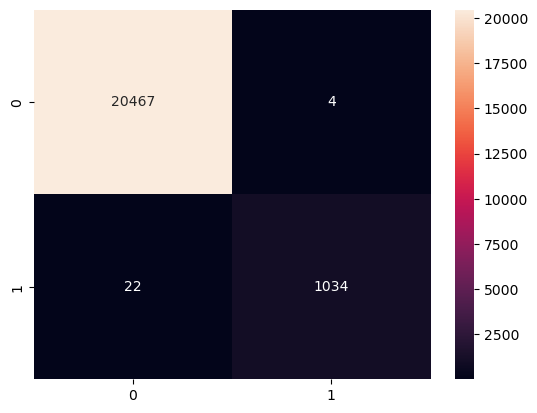

In [9]:
# Create confusion matrix.
cf = confusion_matrix(y_test, y_pred_rf)

# Metrics for accuracy: (TP + TN)/(TP + FP + TN + FN).
print("Accuracy:",metrics.accuracy_score(y_test, y_pred_rf)) 

# Metrics for precision: TP/(TP + FP).
print("Precision:",metrics.precision_score(y_test, y_pred_rf)) 

# Metrics for recall: TP/(FN + TP).
print("Recall:",metrics.recall_score(y_test, y_pred_rf)) 

# Plot the confusion_matrix.
sns.heatmap(cf, annot=True, fmt='g')

The model is overfitting.

In [10]:
y.value_counts()

Completed
0    68421
1     3333
Name: count, dtype: int64

In [11]:
X.columns

Index(['Progressed', 'Registered', 'Centre_Aberdeen', 'Centre_Cardiff',
       'Centre_Durham', 'Centre_Huddersfield', 'Centre_Kingston',
       'Centre_Lancaster', 'Centre_Leeds', 'Centre_Leeds Beckett',
       ...
       'Branch URN_Z9642', 'Branch URN_h26943', 'Branch URN_s26407',
       'Lead Source_APD', 'Lead Source_Sponsor',
       'Lead Source_Standard Agent Booking', 'IntakeYearQuarter_2023.3',
       'IntakeYearQuarter_2023.4', 'IntakeYearQuarter_2024.1',
       'IntakeYearQuarter_2024.2'],
      dtype='object', length=2633)

In [12]:
# Create a new DataFrame and apply SMOTE as the target variable is not balanced.
os = SMOTE(random_state=0)  

# Specify column values.
columns = X.columns  
# Specify the new data sets.
os_data_X,os_data_y=os.fit_resample(X_train, y_train)  

# Create two DataFrames for X and one for y.
os_data_X = pd.DataFrame(data=os_data_X,columns=columns )
os_data_y= pd.DataFrame(data=os_data_y,columns=['Completed'])

# Print/check the DataFrame.
print("Length of oversampled data is ",len(os_data_X))

# Determine if values in a column are balanced.
os_data_y['Completed'].value_counts()

  File "c:\Users\Emmanuel Wagaba\Anaconda3.0\Lib\site-packages\joblib\externals\loky\backend\context.py", line 282, in _count_physical_cores
    raise ValueError(f"found {cpu_count_physical} physical cores < 1")


Length of oversampled data is  95900


Completed
0    47950
1    47950
Name: count, dtype: int64

In [13]:
# Convert y to 1D array
os_data_y = os_data_y.values.ravel()

# Fit the model
rf = RandomForestClassifier()
rf.fit(os_data_X, os_data_y)
os_y_pred_rf = rf.predict(X_test)
print("Random Forest:")
print(classification_report(y_test, os_y_pred_rf))

Random Forest:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     20471
           1       1.00      0.98      0.99      1056

    accuracy                           1.00     21527
   macro avg       1.00      0.99      0.99     21527
weighted avg       1.00      1.00      1.00     21527



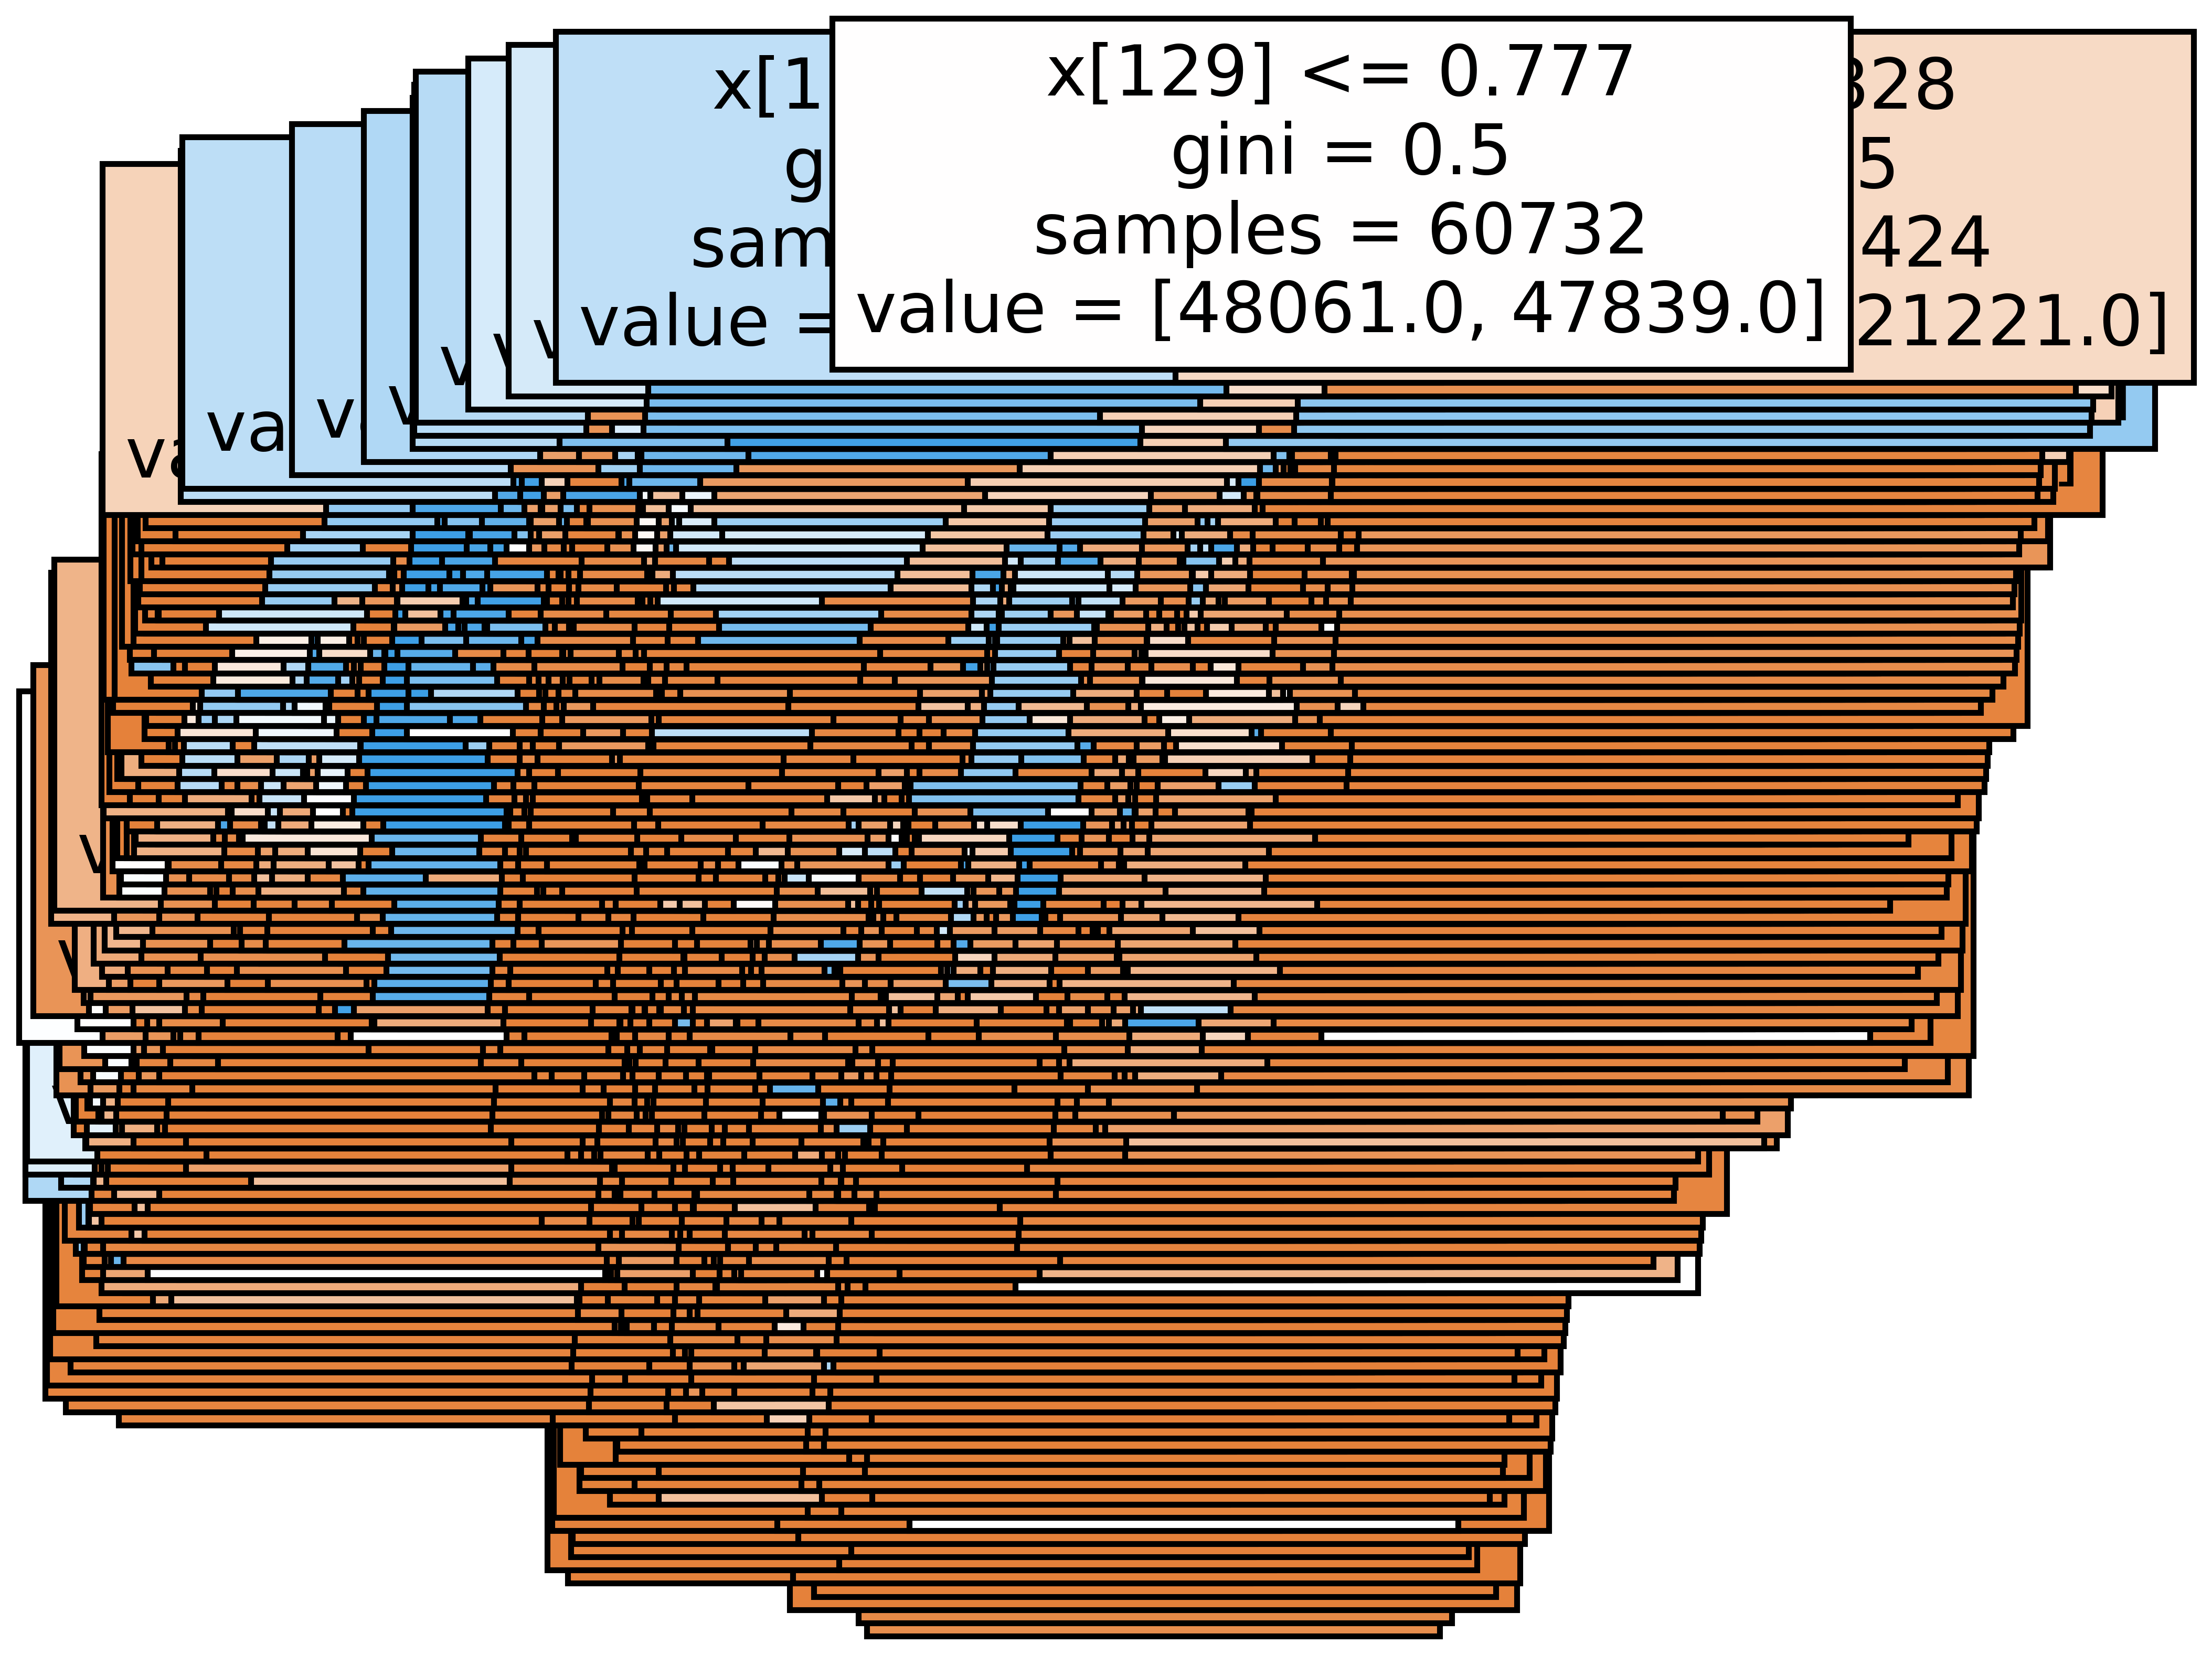

In [14]:
# Plot the first tree from the random forest
fig, axes = plt.subplots(nrows = 1, ncols = 1,
                         figsize = (4,4), dpi=800)
tree.plot_tree(rf.estimators_[0], fontsize=12, 
               filled=True)

# Print the plot with plt.show()
plt.show()

In [15]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)
dt.fit(os_data_X, os_data_y)

DecisionTreeClassifier(random_state=42)

In [16]:
y_pred_dt = dt.predict(X_test)

from sklearn.metrics import classification_report
print("Decision Tree Classification Report:")
print(classification_report(y_test, y_pred_dt))

Decision Tree Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     20471
           1       0.99      0.98      0.98      1056

    accuracy                           1.00     21527
   macro avg       0.99      0.99      0.99     21527
weighted avg       1.00      1.00      1.00     21527



In [17]:
# Predict using the training data
y_train_predicted=dt.predict(X_train)

# Predict using the test data
y_test_predicted=dt.predict(X_test)

# Print accuracy values
print(accuracy_score(y_train,y_train_predicted)) # prediction is the same as the observation
print(accuracy_score(y_test,y_test_predicted)) # prediction on 'unseen data'

0.9993628924681944
0.9984205880986667


In [70]:
# (a) Feature Engineering Review – List all columns
print("Feature columns:")
print(studygroup_dummies.columns.tolist())

Feature columns:
['Completed', 'Progressed', 'Registered', 'Centre_Aberdeen', 'Centre_Cardiff', 'Centre_Durham', 'Centre_Huddersfield', 'Centre_Kingston', 'Centre_Lancaster', 'Centre_Leeds', 'Centre_Leeds Beckett', 'Centre_Liverpool', 'Centre_Royal Holloway', 'Centre_Sheffield', 'Centre_Strathclyde', 'Centre_Surrey', 'Centre_Sussex', 'Centre_Teesside', 'Country_Albania', 'Country_Algeria', 'Country_Angola', 'Country_Anhui', 'Country_Armenia', 'Country_Aus - NSW', 'Country_Aus - Other', 'Country_Aus - QLD', 'Country_Aus - VIC', 'Country_Azerbaijan', 'Country_Bahrain', 'Country_Bangladesh', 'Country_Barbados', 'Country_Beijing', 'Country_Bolivia', 'Country_Botswana', 'Country_Brazil', 'Country_Brunei', 'Country_Bulgaria', 'Country_Cambodia', 'Country_Cameroon', 'Country_Canada', 'Country_Chongqing', 'Country_Colombia', 'Country_Cyprus', 'Country_Ecuador', 'Country_Egypt', 'Country_Fujian', 'Country_Gansu', 'Country_Georgia', 'Country_Germany', 'Country_Ghana', 'Country_Guangdong', 'Count

In [18]:
# Compute the correlation matrix (only works for numeric columns)
studygroup_dummies.head()

Completed  Progressed  Registered  Centre_Aberdeen  Centre_Cardiff  \
0        0.0         0.0         0.0            False           False   
1        0.0         0.0         0.0            False            True   
2        0.0         0.0         0.0            False           False   
3        0.0         0.0         0.0            False           False   
4        0.0         0.0         0.0            False           False   

   Centre_Durham  Centre_Huddersfield  Centre_Kingston  Centre_Lancaster  \
0          False                False            False             False   
1          False                False            False             False   
2          False                False            False             False   
3           True                False            False             False   
4           True                False            False             False   

   Centre_Leeds  Centre_Leeds Beckett  Centre_Liverpool  \
0          True                 False             False   
1         False                 False             False   
2         False                 False             False   
3         False                 False             False   
4         False                 False             False   

   Centre_Royal Holloway  Centre_Sheffield  Centre_Strathclyde  Centre_Surrey  \
0                  False             False               False          False   
1                  False             False               False          False   
2                  False              True               False          False   
3                  False             False               False          False   
4                  False             False               False          False   

   Centre_Sussex  Centre_Teesside  Country_Albania  Country_Algeria  \
0          False            False            False            False   
1          False            False            False            False   
2          False            False            False            False   
3          False            False            False            False   
4          False            False            False            False   

   Country_Angola  Country_Anhui  Country_Armenia  Country_Aus - NSW  \
0           False          False            False              False   
1           False          False            False              False   
2           False          False            False              False   
3           False          False            False              False   
4           False          False            False              False   

   Country_Aus - Other  Country_Aus - QLD  Country_Aus - VIC  \
0                False              False              False   
1                False              False              False   
2                False              False              False   
3                False              False              False   
4                False              False              False   

   Country_Azerbaijan  Country_Bahrain  Country_Bangladesh  Country_Barbados  \
0               False            False               False             False   
1               False            False               False             False   
2               False            False               False             False   
3               False            False               False             False   
4               False            False               False             False   

   Country_Beijing  Country_Bolivia  Country_Botswana  Country_Brazil  \
0            False            False             False           False   
1            False            False             False           False   
2            False            False             False           False   
3             True            False             False           False   
4            False            False             False           False   

   Country_Brunei  Country_Bulgaria  Country_Cambodia  Country_Cameroon  \
0           False        

In [ ]:
# Calculate the correlation matrix
corr_matrix = studygroup_dummies.corr()

# Print the correlations between the features and the target
target_corr = corr_matrix['Completed'].sort_values(ascending=False)
print("\nCorrelation of each feature with the target 'Completed':")
print(target_corr)

In [ ]:
# Visualise the correlation matrix (this can help spot any features with unusually high correlations)
plt.figure(figsize=(12,10))
sns.heatmap(corr_matrix, cmap='coolwarm', annot=False)
plt.title("Correlation Matrix")
plt.show()
